# Modelo Preditivo de Precificação — E-Commerce Brasileiro

## Objetivo
Construir um modelo capaz de prever a faixa de preço de um produto
com base em suas características: categoria, peso, dimensões e frete estimado.

## Abordagem
- Variável alvo: faixa de preço (classificação em 4 faixas)
- Algoritmo: Random Forest + XGBoost
- Avaliação: Acurácia, F1-Score e matriz de confusão
- Tracking: MLflow

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import mlflow.sklearn
import warnings

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
print("Bibliotecas carregadas!")

Bibliotecas carregadas!


## Preparação dos Dados

In [3]:
# Carrega as mesmas tabelas do EDA
DATA_PATH = '../data/raw/'

order_items = pd.read_csv(DATA_PATH + 'olist_order_items_dataset.csv')
products = pd.read_csv(DATA_PATH + 'olist_products_dataset.csv')
orders = pd.read_csv(DATA_PATH + 'olist_orders_dataset.csv')
category_translation = pd.read_csv(DATA_PATH + 'product_category_name_translation.csv')

# Monta o dataset
df = order_items.merge(products, on='product_id', how='left')
df = df.merge(category_translation, on='product_category_name', how='left')
df = df.merge(orders[['order_id', 'order_status']], on='order_id', how='left')

# Apenas entregues
df = df[df['order_status'] == 'delivered'].copy()

# Categoria em inglês
df['categoria'] = df['product_category_name_english'].fillna('sem_categoria')

# Remove outliers de preço (acima do percentil 99)
p99 = df['price'].quantile(0.99)
df = df[df['price'] <= p99].copy()

print(f"Dataset: {df.shape}")
print(f"Preço máximo após filtro: R${df['price'].max():.2f}")

Dataset: (109095, 18)
Preço máximo após filtro: R$887.00


## Criação da Variável Alvo — Faixas de Preço

In [4]:
# Define faixas de preço baseadas nos quartis do EDA
def classificar_faixa(preco):
    if preco <= 40:
        return 0  # Econômico
    elif preco <= 80:
        return 1  # Popular
    elif preco <= 150:
        return 2  # Intermediário
    else:
        return 3  # Premium

df['faixa_preco'] = df['price'].apply(classificar_faixa)

# Distribuição das faixas
faixas = {0: 'Econômico (≤R$40)', 1: 'Popular (R$40–80)',
          2: 'Intermediário (R$80–150)', 3: 'Premium (>R$150)'}

print("Distribuição das faixas de preço:")
for k, v in faixas.items():
    n = (df['faixa_preco'] == k).sum()
    pct = n / len(df) * 100
    print(f"  {v}: {n:,} ({pct:.1f}%)")

Distribuição das faixas de preço:
  Econômico (≤R$40): 28,952 (26.5%)
  Popular (R$40–80): 30,713 (28.2%)
  Intermediário (R$80–150): 28,721 (26.3%)
  Premium (>R$150): 20,709 (19.0%)


### Distribuição das Faixas
- 4 faixas bem distribuídas — sem desbalanceamento crítico
- Faixas definidas com base nos quartis observados no EDA
- Premium (19%) levemente menor — esperado em e-commerce popular

In [5]:
# Features selecionadas
features = [
    'freight_value',
    'product_weight_g',
    'product_length_cm',
    'product_height_cm',
    'product_width_cm',
    'product_photos_qty',
    'product_description_lenght',
    'categoria'
]

df_model = df[features + ['faixa_preco']].dropna().copy()

# Encoding da categoria
le = LabelEncoder()
df_model['categoria_encoded'] = le.fit_transform(df_model['categoria'])

# Features finais
X = df_model[[
    'freight_value',
    'product_weight_g',
    'product_length_cm',
    'product_height_cm',
    'product_width_cm',
    'product_photos_qty',
    'product_description_lenght',
    'categoria_encoded'
]]

y = df_model['faixa_preco']

# Split treino/teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Treino: {X_train.shape}")
print(f"Teste:  {X_test.shape}")
print(f"\nFeatures: {X.columns.tolist()}")

Treino: (86056, 8)
Teste:  (21515, 8)

Features: ['freight_value', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'product_photos_qty', 'product_description_lenght', 'categoria_encoded']


## Treinamento dos Modelos com MLflow

In [6]:


# Configura MLflow
mlflow.set_tracking_uri("sqlite:///../mlflow.db")
mlflow.set_experiment("precificacao-varejo")

# ── Random Forest ──────────────────────────────────────
with mlflow.start_run(run_name="random_forest"):
    rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    y_pred_rf = rf.predict(X_test)
    acc_rf = accuracy_score(y_test, y_pred_rf)

    mlflow.log_param("modelo", "RandomForest")
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("max_depth", 10)
    mlflow.log_metric("acuracia", acc_rf)
    mlflow.sklearn.log_model(rf, "random_forest_model")

    print(f"Random Forest — Acurácia: {acc_rf:.4f}")

# ── XGBoost ────────────────────────────────────────────
with mlflow.start_run(run_name="xgboost"):
    xgb = XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1,
                        random_state=42, eval_metric='mlogloss')
    xgb.fit(X_train, y_train)
    y_pred_xgb = xgb.predict(X_test)
    acc_xgb = accuracy_score(y_test, y_pred_xgb)

    mlflow.log_param("modelo", "XGBoost")
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("max_depth", 6)
    mlflow.log_param("learning_rate", 0.1)
    mlflow.log_metric("acuracia", acc_xgb)
    mlflow.sklearn.log_model(xgb, "xgboost_model")

    print(f"XGBoost      — Acurácia: {acc_xgb:.4f}")

print(f"\nMelhor modelo: {'XGBoost' if acc_xgb > acc_rf else 'Random Forest'}")

2026/05/11 00:14:36 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/11 00:14:36 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Random Forest — Acurácia: 0.6950


2026/05/11 00:14:40 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/11 00:14:40 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


XGBoost      — Acurácia: 0.7157

Melhor modelo: XGBoost


## Avaliação do Modelo Vencedor — XGBoost

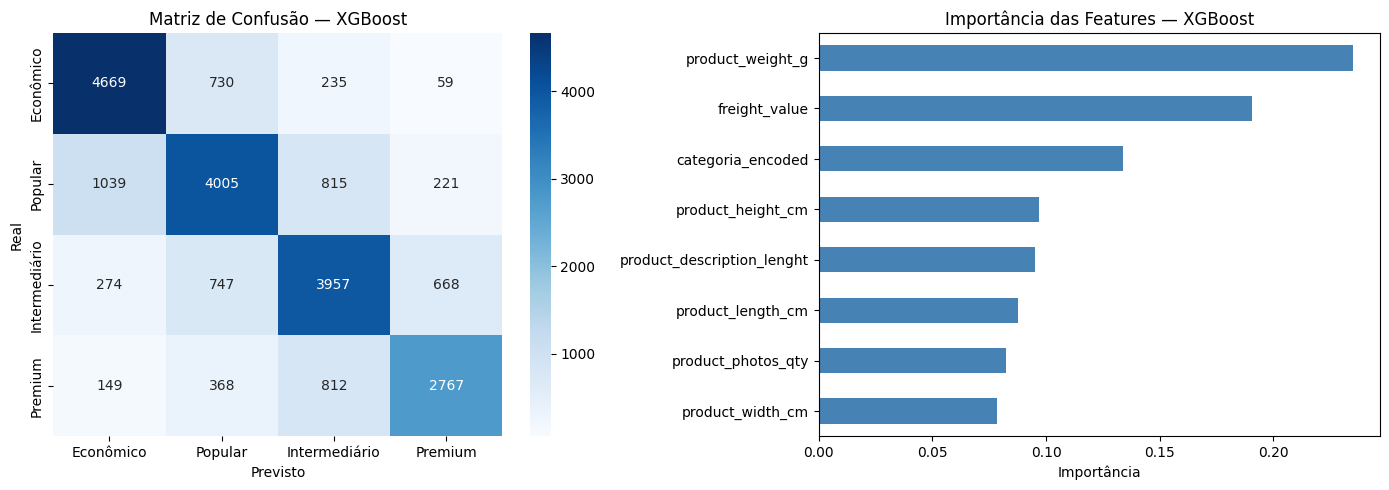

               precision    recall  f1-score   support

    Econômico       0.76      0.82      0.79      5693
      Popular       0.68      0.66      0.67      6080
Intermediário       0.68      0.70      0.69      5646
      Premium       0.74      0.68      0.71      4096

     accuracy                           0.72     21515
    macro avg       0.72      0.71      0.71     21515
 weighted avg       0.72      0.72      0.71     21515



In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusão
faixas_labels = ['Econômico', 'Popular', 'Intermediário', 'Premium']
cm = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=faixas_labels, yticklabels=faixas_labels, ax=axes[0])
axes[0].set_title('Matriz de Confusão — XGBoost', fontsize=12)
axes[0].set_ylabel('Real')
axes[0].set_xlabel('Previsto')

# Feature importance
importancias = pd.Series(xgb.feature_importances_, index=X.columns)
importancias = importancias.sort_values(ascending=True)
importancias.plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Importância das Features — XGBoost', fontsize=12)
axes[1].set_xlabel('Importância')

plt.tight_layout()
plt.savefig('../reports/05_avaliacao_modelo.png', dpi=150, bbox_inches='tight')
plt.show()

# Relatório completo
print(classification_report(y_test, y_pred_xgb, target_names=faixas_labels))

### Insights — Avaliação do Modelo

- **Acurácia geral: 72%** — significativamente acima do baseline aleatório (25%)
- **Econômico** tem melhor performance (F1: 0.79) — faixa mais distinta das demais
- **Popular e Intermediário** têm maior confusão entre si — faixas de preço adjacentes naturalmente se sobrepõem
- **Features mais importantes:**
  - `product_weight_g` — peso é o maior preditor de preço (faz sentido: produtos mais pesados custam mais)
  - `freight_value` — frete correlaciona fortemente com preço e distância
  - `categoria_encoded` — categoria define o posicionamento de preço do produto
- Modelo pronto para produção como baseline de precificação